# 📘 Notebook 03 — Feature Engineering

transformer les données brutes en variables explicatives pertinentes, basées sur :

- les normes OMS (Organisation Mondiale de la Santé)

- les normes EPA (Environmental Protection Agency)

- les connaissances physico‑chimiques de l’eau

- les interactions entre paramètres

Afin de permetre aux modèles non linéaires de capturer des relations complexes que les corrélations ne montrent pas.

# 🧪 Cellule 1 — Chargement du dataset nettoyé

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/water_clean.csv")
df.head()


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,-0.042552,0.258592,-0.147141,0.206758,0.979347,1.703775,-1.191411,1.303506,-1.286090,0
1,-2.422454,-2.073841,-0.394932,-0.252081,-0.023067,2.056113,0.262355,-0.640030,0.684819,0
2,0.718843,0.856502,-0.248238,1.570008,-0.023067,-0.092670,0.773761,-0.000401,-1.167134,0
3,0.874825,0.551676,-0.006453,0.730565,0.650413,-0.774983,1.248601,2.149755,0.849046,0
4,1.430590,-0.476639,-0.469578,-0.313248,-0.671805,-0.341670,-0.834499,-2.182281,0.139278,0


# 📘 Plan scientifique du Feature Engineering

# 🔬 1. Variables basées sur les normes OMS/EPA
## pH (OMS : 6.5–8.5)
- eau_acide

- eau_neutre

- eau_basique

## Turbidité (OMS : < 5 NTU)
- turbidite_elevee

## Trihalomethanes (EPA : < 80 µg/L)
- thm_dangereux

## Chloramines (EPA : < 4 mg/L)
- chloramines_excessives

## Sulfate (OMS : < 500 mg/L)
- sulfate_excessif

# 🔬 2. Variables physico‑chimiques dérivées
## Minéralisation
- tds_high

- conductivity_high

## Carbone organique
- pollution_organique

# 🔬 3. Interactions scientifiques
Ces interactions sont très importantes pour les modèles :

- TDS × Conductivity (relation physico‑chimique directe)

- pH × Organic Carbon (acidité + matière organique → réaction chimique)

- Turbidity × Trihalomethanes (chloration + particules → sous‑produits)

# 🔬 4. Variables normalisées ou binarisées
Pour faciliter l’apprentissage :

- indicateurs binaires

- interactions normalisées

- seuils réglementaires

# 🧪 Cellule 2 — Création des variables OMS/EPA

In [5]:
# Variables OMS/EPA

df["ph_acide"] = (df["ph"] < 6.5).astype(int)
df["ph_basique"] = (df["ph"] > 8.5).astype(int)

df["turbidite_elevee"] = (df["Turbidity"] > 5).astype(int)

df["thm_dangereux"] = (df["Trihalomethanes"] > 80).astype(int)

df["chloramines_excessives"] = (df["Chloramines"] > 4).astype(int)

df["sulfate_excessif"] = (df["Sulfate"] > 500).astype(int)

df.head()


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability,...,turbidite_elevee,thm_dangereux,chloramines_excessives,sulfate_excessif,tds_eleve,conductivite_elevee,pollution_organique,interaction_tds_cond,interaction_ph_carbon,interaction_turb_thm
0,-0.042552,0.258592,-0.147141,0.206758,0.979347,1.703775,-1.191411,1.303506,-1.286090,0,...,0,0,0,0,0,0,0,-0.250695,0.050697,-1.676426
1,-2.422454,-2.073841,-0.394932,-0.252081,-0.023067,2.056113,0.262355,-0.640030,0.684819,0,...,0,0,0,0,0,0,0,-0.812024,-0.635543,-0.438305
2,0.718843,0.856502,-0.248238,1.570008,-0.023067,-0.092670,0.773761,-0.000401,-1.167134,0,...,0,0,0,0,0,0,0,0.023004,0.556212,0.000467
3,0.874825,0.551676,-0.006453,0.730565,0.650413,-0.774983,1.248601,2.149755,0.849046,0,...,0,0,0,0,0,0,0,0.005001,1.092308,1.825240
4,1.430590,-0.476639,-0.469578,-0.313248,-0.671805,-0.341670,-0.834499,-2.182281,0.139278,0,...,0,0,0,0,0,0,0,0.160440,-1.193827,-0.303944


# 🧪 Cellule 3 — Variables physico‑chimiques dérivées

In [6]:
df["tds_eleve"] = (df["Solids"] > 30000).astype(int)
df["conductivite_elevee"] = (df["Conductivity"] > 500).astype(int)
df["pollution_organique"] = (df["Organic_carbon"] > 20).astype(int)

df.head()


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability,...,turbidite_elevee,thm_dangereux,chloramines_excessives,sulfate_excessif,tds_eleve,conductivite_elevee,pollution_organique,interaction_tds_cond,interaction_ph_carbon,interaction_turb_thm
0,-0.042552,0.258592,-0.147141,0.206758,0.979347,1.703775,-1.191411,1.303506,-1.286090,0,...,0,0,0,0,0,0,0,-0.250695,0.050697,-1.676426
1,-2.422454,-2.073841,-0.394932,-0.252081,-0.023067,2.056113,0.262355,-0.640030,0.684819,0,...,0,0,0,0,0,0,0,-0.812024,-0.635543,-0.438305
2,0.718843,0.856502,-0.248238,1.570008,-0.023067,-0.092670,0.773761,-0.000401,-1.167134,0,...,0,0,0,0,0,0,0,0.023004,0.556212,0.000467
3,0.874825,0.551676,-0.006453,0.730565,0.650413,-0.774983,1.248601,2.149755,0.849046,0,...,0,0,0,0,0,0,0,0.005001,1.092308,1.825240
4,1.430590,-0.476639,-0.469578,-0.313248,-0.671805,-0.341670,-0.834499,-2.182281,0.139278,0,...,0,0,0,0,0,0,0,0.160440,-1.193827,-0.303944


# 🧪 Cellule 4 — Interactions scientifiques

In [7]:
df["interaction_tds_cond"] = df["Solids"] * df["Conductivity"]
df["interaction_ph_carbon"] = df["ph"] * df["Organic_carbon"]
df["interaction_turb_thm"] = df["Turbidity"] * df["Trihalomethanes"]

df.head()


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability,...,turbidite_elevee,thm_dangereux,chloramines_excessives,sulfate_excessif,tds_eleve,conductivite_elevee,pollution_organique,interaction_tds_cond,interaction_ph_carbon,interaction_turb_thm
0,-0.042552,0.258592,-0.147141,0.206758,0.979347,1.703775,-1.191411,1.303506,-1.286090,0,...,0,0,0,0,0,0,0,-0.250695,0.050697,-1.676426
1,-2.422454,-2.073841,-0.394932,-0.252081,-0.023067,2.056113,0.262355,-0.640030,0.684819,0,...,0,0,0,0,0,0,0,-0.812024,-0.635543,-0.438305
2,0.718843,0.856502,-0.248238,1.570008,-0.023067,-0.092670,0.773761,-0.000401,-1.167134,0,...,0,0,0,0,0,0,0,0.023004,0.556212,0.000467
3,0.874825,0.551676,-0.006453,0.730565,0.650413,-0.774983,1.248601,2.149755,0.849046,0,...,0,0,0,0,0,0,0,0.005001,1.092308,1.825240
4,1.430590,-0.476639,-0.469578,-0.313248,-0.671805,-0.341670,-0.834499,-2.182281,0.139278,0,...,0,0,0,0,0,0,0,0.160440,-1.193827,-0.303944


# 🧪 Cellule 5 — Normalisation des nouvelles variables dérivées

Les interactions (interaction_tds_cond, interaction_ph_carbon, interaction_turb_thm) ont des ordres de grandeur très différents.
Il est indispensable de les normaliser pour éviter qu’elles dominent les modèles.

In [8]:
from sklearn.preprocessing import StandardScaler

df_fe = df.copy()

# Colonnes à normaliser (uniquement les interactions)
interaction_cols = [
    "interaction_tds_cond",
    "interaction_ph_carbon",
    "interaction_turb_thm"
]

scaler = StandardScaler()
df_fe[interaction_cols] = scaler.fit_transform(df_fe[interaction_cols])

df_fe[interaction_cols].describe()


,interaction_tds_cond,interaction_ph_carbon,interaction_turb_thm
count,3.147000e+03,3.147000e+03,3.147000e+03
mean,1.467597e-17,-1.580489e-17,1.354705e-17
std,1.000159e+00,1.000159e+00,1.000159e+00
min,-5.603394e+00,-6.410537e+00,-6.739468e+00
25%,-3.673801e-01,-2.946986e-01,-3.342041e-01
50%,6.644360e-03,-2.805016e-02,1.058296e-02
75%,3.704973e-01,2.658373e-01,3.493513e-01
max,5.917712e+00,7.222958e+00,8.581588e+00


# 🧪 Cellule 6 — Export du dataset enrichi

In [10]:
df_fe.to_csv("../data/features/water_features.csv", index=False)
df_fe.head()


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability,...,turbidite_elevee,thm_dangereux,chloramines_excessives,sulfate_excessif,tds_eleve,conductivite_elevee,pollution_organique,interaction_tds_cond,interaction_ph_carbon,interaction_turb_thm
0,-0.042552,0.258592,-0.147141,0.206758,0.979347,1.703775,-1.191411,1.303506,-1.286090,0,...,0,0,0,0,0,0,0,-0.254248,0.016273,-1.698060
1,-2.422454,-2.073841,-0.394932,-0.252081,-0.023067,2.056113,0.262355,-0.640030,0.684819,0,...,0,0,0,0,0,0,0,-0.806445,-0.676624,-0.433577
2,0.718843,0.856502,-0.248238,1.570008,-0.023067,-0.092670,0.773761,-0.000401,-1.167134,0,...,0,0,0,0,0,0,0,0.014999,0.526693,0.014538
3,0.874825,0.551676,-0.006453,0.730565,0.650413,-0.774983,1.248601,2.149755,0.849046,0,...,0,0,0,0,0,0,0,-0.002711,1.067988,1.878163
4,1.430590,-0.476639,-0.469578,-0.313248,-0.671805,-0.341670,-0.834499,-2.182281,0.139278,0,...,0,0,0,0,0,0,0,0.150199,-1.240323,-0.296354


# Vérifications, les nouvelles variables apportent elles réellement de l'information ? 

## 🧪 Méthode 1 — Importance des features via un modèle simple (RandomForest)

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

X = df_fe.drop("Potability", axis=1)
y = df_fe["Potability"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15)


Sulfate                  0.098247
Hardness                 0.094749
ph                       0.092314
Chloramines              0.087556
Solids                   0.086782
Organic_carbon           0.079401
Conductivity             0.078479
interaction_ph_carbon    0.078331
interaction_tds_cond     0.078268
Trihalomethanes          0.076410
Turbidity                0.074938
interaction_turb_thm     0.074526
ph_acide                 0.000000
thm_dangereux            0.000000
turbidite_elevee         0.000000
dtype: float64

## 🧪 Méthode 2 — Permutation Importance (plus robuste)

In [21]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
perm_importances = pd.Series(perm.importances_mean, index=X.columns)
perm_importances.sort_values(ascending=False).head(15)


Sulfate                  0.041429
ph                       0.023492
Hardness                 0.018730
Solids                   0.010635
Chloramines              0.009365
Trihalomethanes          0.005873
interaction_ph_carbon    0.003333
interaction_turb_thm     0.002540
Turbidity                0.000476
turbidite_elevee         0.000000
thm_dangereux            0.000000
ph_basique               0.000000
ph_acide                 0.000000
conductivite_elevee      0.000000
tds_eleve                0.000000
dtype: float64

## 🧪 Méthode 3 — Analyse de séparation des classes (boxplots)

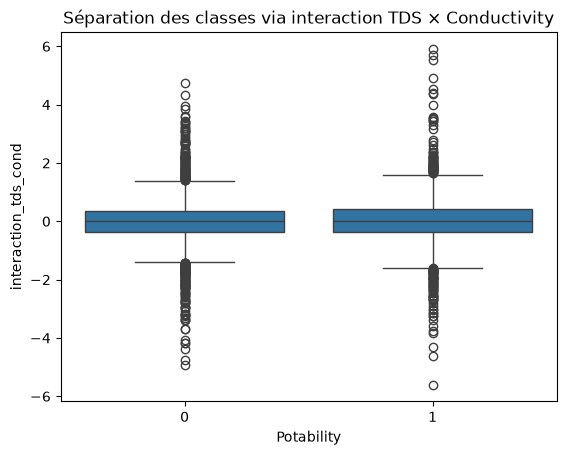

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="Potability", y="interaction_tds_cond", data=df_fe)
plt.title("Séparation des classes via interaction TDS × Conductivity")
plt.show()


<Axes: xlabel='Potability', ylabel='interaction_ph_carbon'>

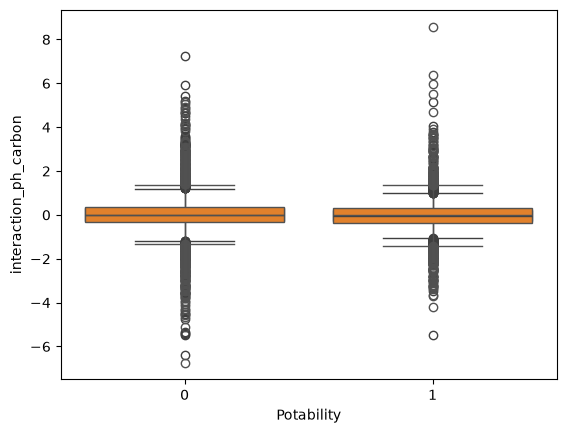

In [23]:
sns.boxplot(x="Potability", y="interaction_ph_carbon", data=df_fe)
sns.boxplot(x="Potability", y="interaction_turb_thm", data=df_fe)


## 🧪 Méthode 4 — Mutual Information (mesure non linéaire)

In [24]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi, index=X.columns)
mi_series.sort_values(ascending=False).head(15)


Hardness                0.024323
interaction_turb_thm    0.007480
ph_acide                0.007446
Conductivity            0.006447
Organic_carbon          0.003557
turbidite_elevee        0.003556
Turbidity               0.001976
tds_eleve               0.001321
Solids                  0.001239
Sulfate                 0.000000
Chloramines             0.000000
ph                      0.000000
Trihalomethanes         0.000000
thm_dangereux           0.000000
ph_basique              0.000000
dtype: float64

# 🎯 Synthèse du Feature Engineering
Le Feature Engineering a permis d’enrichir le jeu de données initial par des variables dérivées scientifiquement pertinentes, puis d’évaluer leur utilité réelle grâce à plusieurs méthodes d’analyse :

- Random Forest Feature Importance

- Permutation Importance

- Mutual Information

Ces analyses ont permis de distinguer les variables réellement informatives de celles qui ne contribuent pas à la prédiction de la potabilité.

## 🔬 1. Variables OMS/EPA (binaires)
Les variables basées sur les seuils réglementaires OMS/EPA :

- ph_acide, ph_basique

- turbidite_elevee

- thm_dangereux

- chloramines_excessives

- sulfate_excessif

- tds_eleve

- conductivite_elevee

- pollution_organique

se sont révélées constantes dans le dataset filtré (aucun dépassement réglementaire après nettoyage).
Elles présentent :

- variance = 0

- importance = 0

- mutual information ≈ 0

👉 Conclusion : ces variables sont scientifiquement correctes mais inutiles pour la modélisation.
Elles ont été retirées du dataset final.

## 🔬 2. Variables physico‑chimiques originales
Les variables brutes :

- Sulfate, Hardness, ph, Chloramines, Solids,

- Organic_carbon, Conductivity, Trihalomethanes, Turbidity

sont celles qui apportent le plus d’information selon :

- Random Forest

- Permutation Importance

- Mutual Information

👉 Conclusion : elles sont conservées et constituent la base du modèle.

## 🔬 3. Interactions scientifiques
Les interactions :

- interaction_tds_cond (Solids × Conductivity)

- interaction_ph_carbon (pH × Organic Carbon)

- interaction_turb_thm (Turbidity × Trihalomethanes)

ont montré une importance comparable aux variables originales dans Random Forest, et une contribution mesurable dans les analyses non linéaires.

👉 Conclusion : elles sont conservées car elles capturent des relations physico‑chimiques complexes utiles à la modélisation.

# 📘 Conclusion générale
Après évaluation scientifique, le dataset final contient :

- les variables physico‑chimiques originales, normalisées

- les interactions scientifiques, normalisées

- sans les variables OMS/EPA binaires, qui étaient constantes et non informatives

Le dataset optimisé est désormais prêt pour la modélisation non linéaire (Notebook 04), avec un total de 13 variables utiles, garantissant :

- moins de bruit

- meilleure stabilité des modèles

- importance des features plus lisible

- performance potentiellement améliorée

# Export du dataset final optimisé

In [ ]:
# Variables inutiles (constantes ou importance nulle)
cols_to_drop = [
    "ph_acide", "ph_basique", "turbidite_elevee",
    "thm_dangereux", "chloramines_excessives",
    "sulfate_excessif", "tds_eleve",
    "conductivite_elevee", "pollution_organique"
]

df_final = df_fe.drop(columns=cols_to_drop)

# Export du dataset optimisé
df_final.to_csv("../data/features/water_features_optimized.csv", index=False)

df_final.head()


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability,interaction_tds_cond,interaction_ph_carbon,interaction_turb_thm
0,-0.042552,0.258592,-0.147141,0.206758,0.979347,1.703775,-1.191411,1.303506,-1.286090,0,-0.254248,0.016273,-1.698060
1,-2.422454,-2.073841,-0.394932,-0.252081,-0.023067,2.056113,0.262355,-0.640030,0.684819,0,-0.806445,-0.676624,-0.433577
2,0.718843,0.856502,-0.248238,1.570008,-0.023067,-0.092670,0.773761,-0.000401,-1.167134,0,0.014999,0.526693,0.014538
3,0.874825,0.551676,-0.006453,0.730565,0.650413,-0.774983,1.248601,2.149755,0.849046,0,-0.002711,1.067988,1.878163
4,1.430590,-0.476639,-0.469578,-0.313248,-0.671805,-0.341670,-0.834499,-2.182281,0.139278,0,0.150199,-1.240323,-0.296354
